In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os
import cv2

In [2]:
os.listdir('TB_Chest_Radiography_Database/')

['.ipynb_checkpoints', 'Normal', 'Tuberculosis']

In [3]:
im = mpimg.imread('TB_Chest_Radiography_Database/Normal/Normal-1448.png')

In [4]:
im

array([[[0.00784314, 0.00784314, 0.00784314],
        [0.05098039, 0.05098039, 0.05098039],
        [0.04313726, 0.04313726, 0.04313726],
        ...,
        [0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        ]],

       [[0.00784314, 0.00784314, 0.00784314],
        [0.05882353, 0.05882353, 0.05882353],
        [0.05882353, 0.05882353, 0.05882353],
        ...,
        [0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        ]],

       [[0.00392157, 0.00392157, 0.00392157],
        [0.05490196, 0.05490196, 0.05490196],
        [0.05490196, 0.05490196, 0.05490196],
        ...,
        [0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        ]],

       ...,

       [[0.0627451 , 0.0627451 , 0.0627451 ],
        [0.7921569 , 0.7921569 , 0.7921569 ],
        [0.89411765, 0

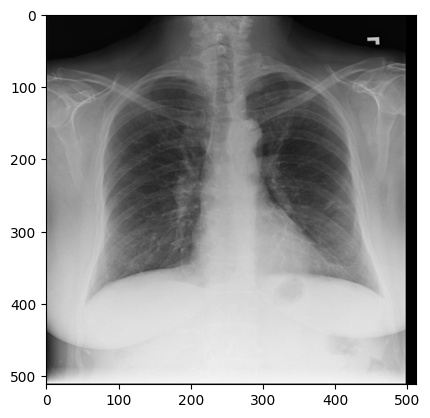

In [5]:
plt.imshow(im)

In [6]:
X = []
y = []
labels = {
    'Normal':0,
    'Tuberculosis':1
}
for i in os.listdir('TB_Chest_Radiography_Database/'):
    for j in os.listdir(f'TB_Chest_Radiography_Database/{i}/'):
        try:
            image = mpimg.imread(f'TB_Chest_Radiography_Database/{i}/{j}')
            if len(image.shape) == 3 and image.shape[2] == 3:
                image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
            elif len(image.shape) == 3 and image.shape[2] != 3:
                image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
            image = cv2.resize(image, (150, 150))
            image = image.reshape(150, 150, 1)
            X.append(image)
            y.append(labels[i])
        except:
            continue
X = np.array(X)
y = np.array(y)

In [7]:
X.shape

(4200, 150, 150, 1)

In [8]:
X

array([[[[0.01487582],
         [0.01176471],
         [0.01176471],
         ...,
         [0.06075904],
         [0.04368941],
         [0.05758414]],

        [[0.01176471],
         [0.01176471],
         [0.01176471],
         ...,
         [0.01568628],
         [0.01568628],
         [0.01487582]],

        [[0.01176471],
         [0.01176471],
         [0.01176471],
         ...,
         [0.01568628],
         [0.01568628],
         [0.01568628]],

        ...,

        [[0.01568628],
         [0.01568628],
         [0.01555556],
         ...,
         [0.02745098],
         [0.02745098],
         [0.02826144]],

        [[0.01568628],
         [0.01568628],
         [0.01171503],
         ...,
         [0.02745098],
         [0.02745098],
         [0.03056209]],

        [[0.01568628],
         [0.01375739],
         [0.01487582],
         ...,
         [0.02745098],
         [0.03168052],
         [0.03218301]]],


       [[[0.9132966 ],
         [0.87580234],
         [0.83

In [9]:
y.shape

(4200,)

In [10]:
from sklearn.model_selection import train_test_split

In [11]:
from keras.utils import to_categorical

In [12]:
y = to_categorical(y, num_classes=2)

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [14]:
from keras import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from keras.optimizers import Adam

In [15]:
X_train.shape

(3360, 150, 150, 1)

In [16]:
y_train.shape

(3360, 2)

In [17]:
model = Sequential()

model.add(Conv2D(filters=32, kernel_size=(5, 5), activation='relu', input_shape=(150, 150, 1)))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(filters=32, kernel_size=(3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Flatten())

model.add(Dense(units=120, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(units=60, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(units=20, activation='relu'))
model.add(Dense(units=2, activation='softmax'))

C:\Users\ASUS\Desktop\ML_18-35_Jupyter\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [18]:
model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])

In [19]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 146, 146, 32)        │             832 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 73, 73, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 71, 71, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 35, 35, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 39200)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 120)                 │       4,704,120 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 120)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 60)                  │           7,260 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 60)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 20)                  │           1,220 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 2)                   │              42 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,722,722 (18.02 MB)

 Trainable params: 4,722,722 (18.02 MB)

 Non-trainable params: 0 (0.00 B)

In [20]:
model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=10)

Epoch 1/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 13s 102ms/step - accuracy: 0.8458 - loss: 0.3429 - val_accuracy: 0.9095 - val_loss: 0.2362
Epoch 2/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 20s 99ms/step - accuracy: 0.9152 - loss: 0.2055 - val_accuracy: 0.9321 - val_loss: 0.1759
Epoch 3/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 10s 99ms/step - accuracy: 0.9372 - loss: 0.1849 - val_accuracy: 0.9393 - val_loss: 0.1562
Epoch 4/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 10s 99ms/step - accuracy: 0.9545 - loss: 0.1355 - val_accuracy: 0.9452 - val_loss: 0.1472
Epoch 5/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 11s 100ms/step - accuracy: 0.9622 - loss: 0.1044 - val_accuracy: 0.9560 - val_loss: 0.1245
Epoch 6/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 10s 99ms/step - accuracy: 0.9688 - loss: 0.0853 - val_accuracy: 0.9571 - val_loss: 0.1445
Epoch 7/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 21s 99ms/step - accuracy: 0.9777 - loss: 0.0698 - val_accuracy: 0.9536 - val_loss: 0.1351
Epoch 8/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 21s 99ms/step - accuracy: 0.9747 - loss: 0.0688 

In [25]:

image = mpimg.imread('images (7).jpg')

In [26]:
image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
image = cv2.resize(image, (150, 150))
image = image.reshape(1, 150, 150, 1)

In [29]:
y_pred = model.predict(image)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


In [28]:
predict_labels = {
    0:"Normal",
    1:"Tuberculosis"
}

In [34]:
predict_labels[np.argmax(y_pred)]

'Tuberculosis'

In [35]:
y_pred

array([[1.5182498e-35, 1.0000000e+00]], dtype=float32)

In [36]:
import pickle

In [37]:
with open('model.pkl', 'wb') as file:
    pickle.dump(model, file)